In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
import os
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
import keras
from tensorflow.keras import layers, Sequential
from PIL import Image
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers
from tensorflow.keras.applications import VGG16
from scipy.stats import mode
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import layers, models
from zipfile import ZipFile

In [ ]:

Directory = '/content/drive/MyDrive/real amd fake images.zip'

with ZipFile(Directory, 'r') as zip:
    zip.extractall()
    print('images are uploaded.')

images are uploaded.


In [ ]:
# Assuming your real and fake images are in different paths
actual_path = "/content/ffhq images"
phony_path = "/content/dcgan images"

# Get a list of image files in the real and fake directories
list_actual_picture = [f for f in os.listdir(actual_path) ]
list_phony_picture = [f for f in os.listdir(phony_path) ]

# Load and preprocess real and fake images
def preprocess_image(path_picture):
    pic = Image.open(path_picture)
    pic = pic.resize((200, 200))
    pic = np.array(pic)
    pic = pic / 255.0  # Normalize pixel values
    return pic

original_picture = [preprocess_image(os.path.join(actual_path, pic)) for pic in list_actual_picture]
phony_picture = [preprocess_image(os.path.join(phony_path, pic)) for pic in list_phony_picture]

# Create tags (1 for real, 0 for fake)
original_tag = np.ones(len(original_picture))
phony_tag = np.zeros(len(phony_picture))

# Combine picture and tags
pictures = np.concatenate((original_picture, phony_picture))
tags = np.concatenate((original_tag, phony_tag))

In [ ]:
# Split the dataset into train and test sets,
trainx, testx, trainy, testy = train_test_split(pictures, tags, test_size=0.2, random_state=8)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


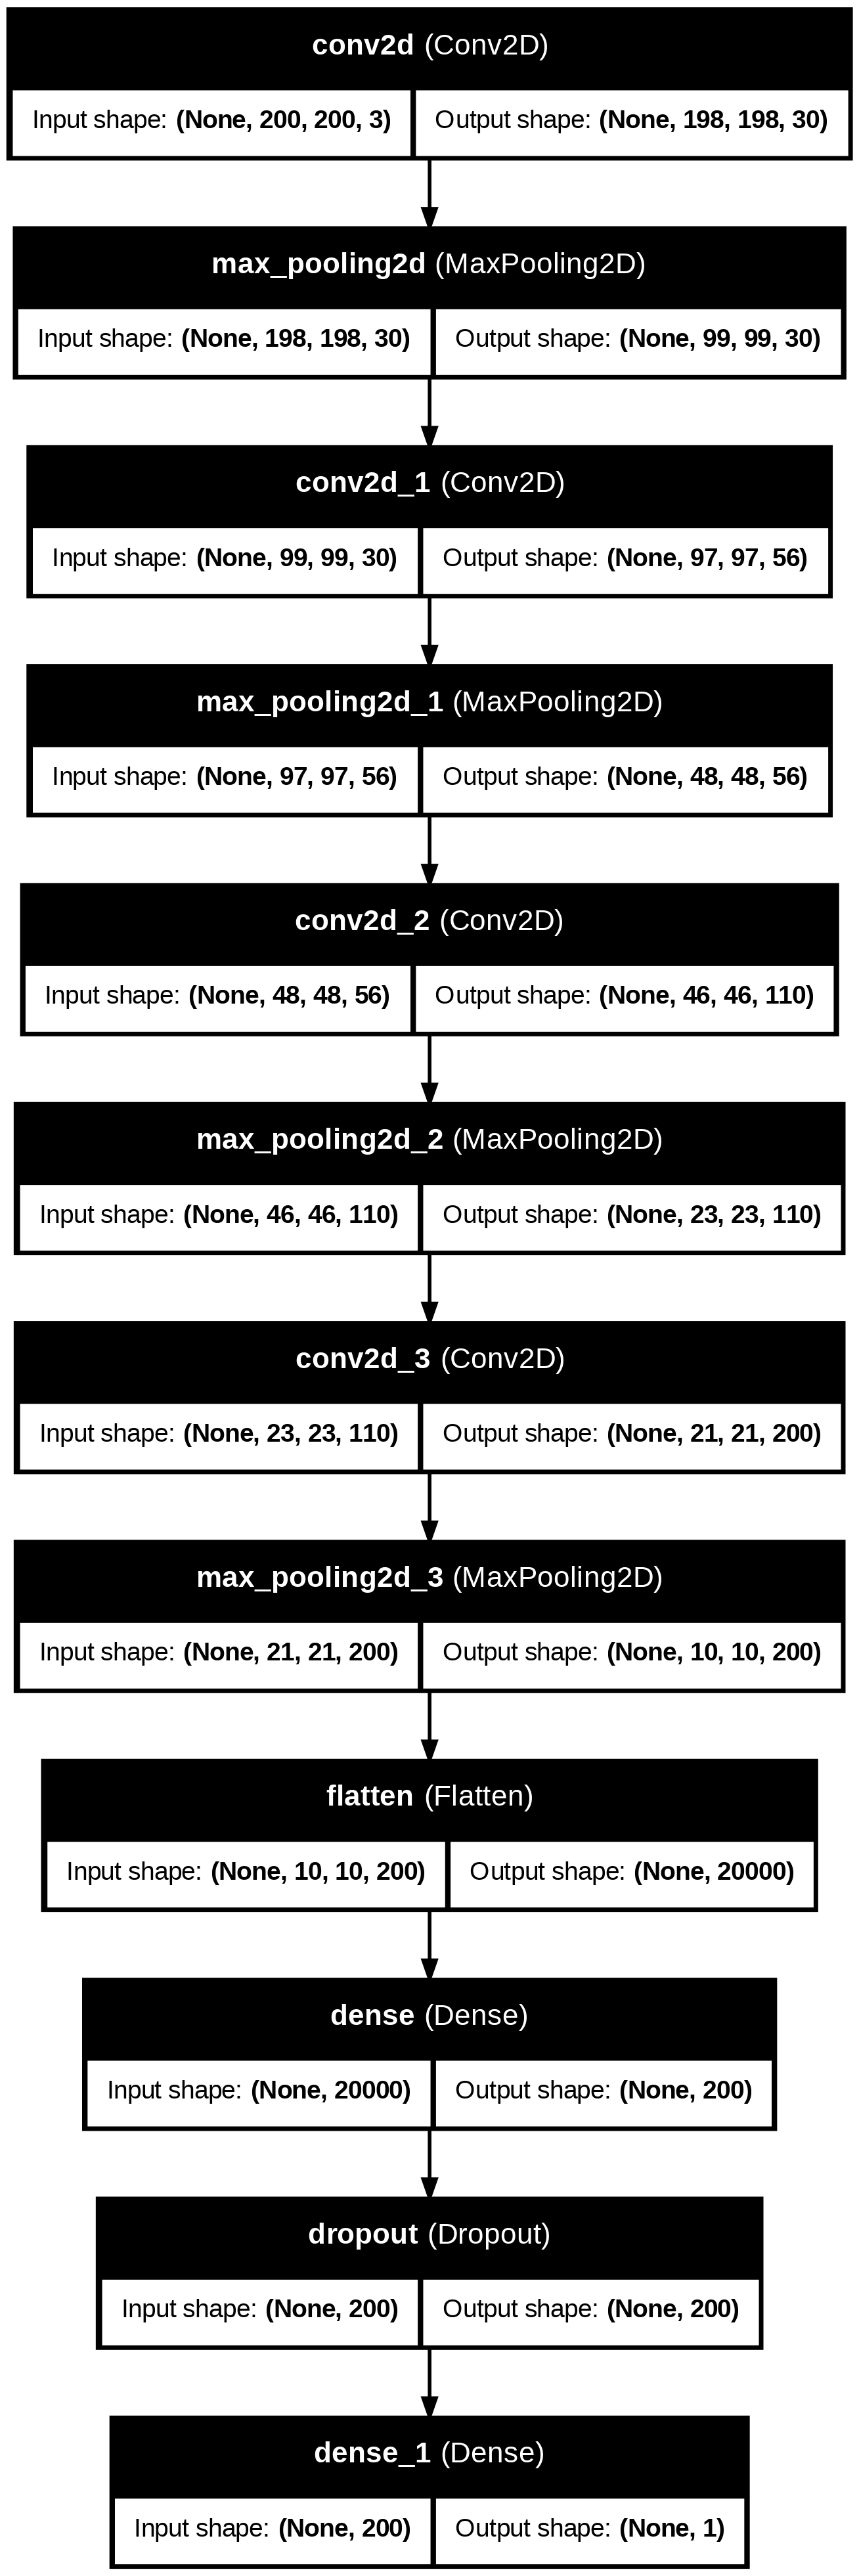

In [ ]:
inputshape = (200, 200, 3)
prototype = models.Sequential()
prototype.add(layers.Conv2D(30, (3,3), activation='relu', input_shape= inputshape,))
prototype.add(layers.MaxPooling2D(2, 2))
prototype.add(layers.Conv2D(56, (3, 3), activation='relu',))
prototype.add(layers.MaxPooling2D(2, 2))
prototype.add(layers.Conv2D(110, (3, 3), activation='relu',))
prototype.add(layers.MaxPooling2D(2, 2))
prototype.add(layers.Conv2D(200, (3, 3), activation='relu',))
prototype.add(layers.MaxPooling2D(2, 2))
prototype.add(layers.Flatten())
prototype.add(layers.Dense(200, activation='relu'))
prototype.add(layers.Dropout(0.4))
prototype.add(layers.Dense(1, activation='sigmoid'))

# Compile the protyotype
prototype.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['acc'])


# Plot the prototype architecture
plot_model(prototype, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Train the model with callbacks, mini-batch size, and specified momentum
record = prototype.fit(trainx, trainy,
                    epochs=100,
                    validation_data=(testx, testy),
                    batch_size=128,  # Adding mini-batch size
                    verbose=1)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - acc: 0.4577 - loss: 0.7694 - val_acc: 0.5926 - val_loss: 0.6573
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - acc: 0.4761 - loss: 0.7040 - val_acc: 0.6173 - val_loss: 0.6791
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - acc: 0.5462 - loss: 0.6881 - val_acc: 0.5926 - val_loss: 0.6528
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - acc: 0.4980 - loss: 0.6821 - val_acc: 0.8148 - val_loss: 0.6445
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - acc: 0.6629 - loss: 0.6628 - val_acc: 0.8272 - val_loss: 0.5755
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - acc: 0.7056 - loss: 0.6135 - val_acc: 0.6420 - val_loss: 0.5716
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - acc: 0.6158 - loss: 0.6567 - val_acc: 0.7654 - val_loss: 0.5765
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - acc: 0.6906 - loss: 0.6012 - val_acc: 0.7407 - val_loss: 0.5494
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - acc: 0.6837 

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step


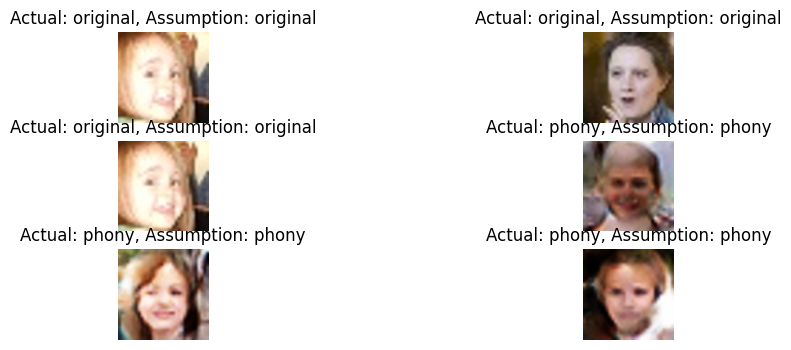

In [ ]:
# Make predictions on the test set
dope_y = prototype.predict(testx)

# Visualize some random images along with their predicted labels
representation = 7
horizental_lines = 3
vertical_lines = representation // horizental_lines
level, axis = plt.subplots(horizental_lines, vertical_lines, figsize=(11, 4))

for i in range(horizental_lines):
    for j in range(vertical_lines):
        idx = np.random.randint(len(testx))
        pictures = testx[idx]
        original_tag = "original" if testy[idx] == 1 else "phony"
        phony_tag = "original" if dope_y[idx] >= 0.5 else "phony"

        axis[i, j].imshow(pictures)
        axis[i, j].set_title(f"Actual: {original_tag}, Assumption: {phony_tag}")
        axis[i, j].axis('off')

plt.show()

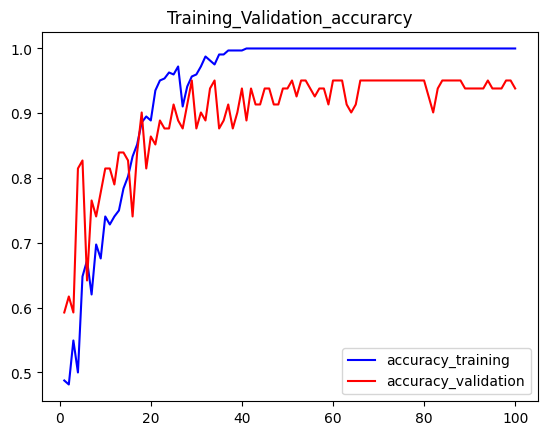

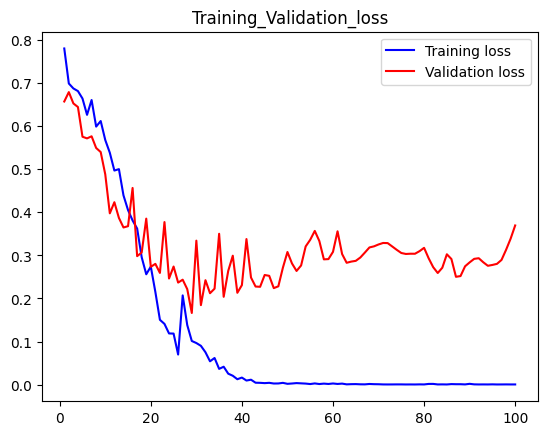

In [ ]:
acc = record.history['acc']
val_acc = record.history['val_acc']
loss = record.history['loss']
val_loss = record.history['val_loss']
epochs = range(1, len(acc) + 1)
#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='accuracy_training')
plt.plot(epochs, val_acc, 'r', label='accuracy_validation')
plt.title('Training_Validation_accurarcy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training_Validation_loss')
plt.legend()
plt.show()


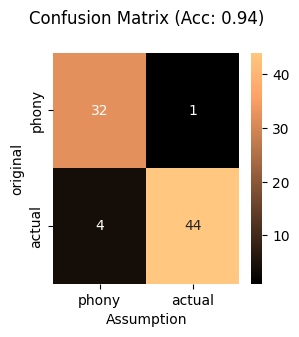

In [ ]:

dope_y_assumption = (dope_y > 0.5).astype(int)



# Generate a confusion matrix
cm = confusion_matrix(testy, dope_y_assumption)

# Plot the confusion matrix with labels and numbers
plt.figure(figsize=(3, 3))

sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.copper, cbar=True)
plt.xlabel('Assumption')
plt.ylabel('original')
plt.xticks([0.5, 1.5], ['phony', 'actual'])
plt.yticks([0.5, 1.5], ['phony', 'actual'])
plt.title(f'Confusion Matrix (Acc: {accuracy_score(testy, dope_y_assumption):.2f})\n')
plt.show()

In [ ]:
report = classification_report(testy, dope_y_assumption)
print(report)

              precision    recall  f1-score   support

         0.0       0.89      0.97      0.93        33
         1.0       0.98      0.92      0.95        48

    accuracy                           0.94        81
   macro avg       0.93      0.94      0.94        81
weighted avg       0.94      0.94      0.94        81



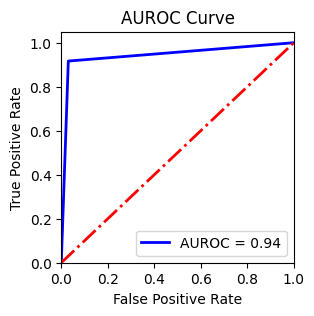

In [ ]:
# Compute the AUROC score for each class (assuming binary classification)
fpr, tpr, _ = roc_curve(testy, dope_y_assumption)
auroc_curve = auc(fpr, tpr)


plt.figure(figsize=(3,3))
#plt.plot(testy, dope_y_assumption, 'b-', linewidth=2)
plt.plot(fpr, tpr, 'b-', linewidth=2, label='AUROC = %0.2f' % auroc_curve)
plt.plot([0, 1], [0, 1], color='red', linewidth=2, ls='dashdot')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


plt.title('AUROC Curve')
plt.legend(loc='lower right')
plt.show()
